In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Get Salex Lexicon 

In [94]:
SALEX = pd.read_csv('salex_nrc.csv').set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


## Reading in the LIB and Tokens table

In [95]:
LIB = pd.read_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/DATA/LIB.csv', index_col='mag_id').sort_index()
TOKENS = pd.read_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/DATA/CORPUS.csv', index_col=['mag_id','page_num','token_num']).sort_index()
TOKENS = TOKENS.join(LIB)
TOKENS.head()

pos pos_group token_str term_str       epub_id  \
mag_id page_num token_num                                                  
0      1        0          DT        DT       The      the  vo8DAAAAMBAJ   
                1          NN        NN      text     text  vo8DAAAAMBAJ   
                2          IN        IN        on       on  vo8DAAAAMBAJ   
                3          DT        DT      this     this  vo8DAAAAMBAJ   
                4          NN        NN      page     page  vo8DAAAAMBAJ   

                                 date  \
mag_id page_num token_num               
0      1        0          1972-12-07   
                1          1972-12-07   
                2          1972-12-07   
                3          1972-12-07   
                4          1972-12-07   

                                                                       pages  \
mag_id page_num token_num                                                      
0      1        0          ["\n\n\n\nThis book was produced in EPUB forma...   
                1          ["\n\n\n\nThis book was produced in EPUB forma...   
                2          ["\n\n\n\nThis book was produced in EPUB forma...   
                3          ["\n\n\n\nThis book was produced in EPUB forma...   
                4          ["\n\n\n\nThis book was produced in EPUB forma...   

                           month      quarter  page_num  \
mag_id page_num token_num                                 
0      1        0             12  4th Quarter        68   
                1             12  4th Quarter        68   
                2             12  4th Quarter        68   
                3             12  4th Quarter        68   
                4             12  4th Quarter        68   

                                                                       title  \
mag_id page_num token_num                                                      
0      1        0          What Dope Arrest is Doing to Career of Barbara...   
                1          What Dope Arrest is Doing to Career of Barbara...   
                2          What Dope Arrest is Doing to Career of Barbara...   
                3          What Dope Arrest is Doing to Career of Barbara...   
                4          What Dope Arrest is Doing to Career of Barbara...   

                           character_len  
mag_id page_num token_num                 
0      1        0                  99374  
                1                  99374  
                2                  99374  
                3                  99374  
                4                  99374

In [96]:
TOKENS.shape

(131948, 12)

In [97]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left').fillna(0)
TOKENS_SA

pos pos_group token_str  term_str       epub_id  \
mag_id page_num token_num                                                    
0      1        0           DT        DT       The       the  vo8DAAAAMBAJ   
                1           NN        NN      text      text  vo8DAAAAMBAJ   
                2           IN        IN        on        on  vo8DAAAAMBAJ   
                3           DT        DT      this      this  vo8DAAAAMBAJ   
                4           NN        NN      page      page  vo8DAAAAMBAJ   
...                        ...       ...       ...       ...           ...   
9      68       55         NNP        NN      INC.       inc  mEEDAAAAMBAJ   
                57         NNP        NN  Michigan  michigan  mEEDAAAAMBAJ   
                58         NNP        NN    Avenue    avenue  mEEDAAAAMBAJ   
                60         NNP        NN   Chicago   chicago  mEEDAAAAMBAJ   
                62         NNP        NN  Illinois  illinois  mEEDAAAAMBAJ   

                                 date  \
mag_id page_num token_num               
0      1        0          1972-12-07   
                1          1972-12-07   
                2          1972-12-07   
                3          1972-12-07   
                4          1972-12-07   
...                               ...   
9      68       55         1959-04-09   
                57         1959-04-09   
                58         1959-04-09   
                60         1959-04-09   
                62         1959-04-09   

                                                                       pages  \
mag_id page_num token_num                                                      
0      1        0          ["\n\n\n\nThis book was produced in EPUB forma...   
                1          ["\n\n\n\nThis book was produced in EPUB forma...   
                2          ["\n\n\n\nThis book was produced in EPUB forma...   
                3          ["\n\n\n\nThis book was produced in EPUB forma...   
                4          ["\n\n\n\nThis book was produced in EPUB forma...   
...                                                                      ...   
9      68       55         ["\n\n\n\nThis book was produced in EPUB forma...   
                57         ["\n\n\n\nThis book was produced in EPUB forma...   
                58         ["\n\n\n\nThis book was produced in EPUB forma...   
                60         ["\n\n\n\nThis book was produced in EPUB forma...   
                62         ["\n\n\n\nThis book was produced in EPUB forma...   

                           month      quarter  page_num  ... anticipation  \
mag_id page_num token_num                                ...                
0      1        0             12  4th Quarter        68  ...          0.0   
                1             12  4th Quarter        68  ...          0.0   
                2             12  4th Quarter        68  ...          0.0   
                3             12  4th Quarter        68  ...          0.0   
                4             12  4th Quarter        68  ...          0.0   
...                          ...          ...       ...  ...          ...   
9      68       55             4  2nd Quarter        68  ...          0.0   
                57             4  2nd Quarter        68  ...          0.0   
                58             4  2nd Quarter        68  ...          0.0   
                60             4  2nd Quarter        68  ...          0.0   
                62             4  2nd Quarter        68  ...          0.0   

                           disgust  fear  joy  negative  positive  sadness  \
mag_id page_num token_num                                                    
0      1        0              0.0   0.0  0.0       0.0       0.0      0.0   
                1              0.0   0.0  0.0       0.0       0.0      0.0   
                2              0.0   0.0  0.0       0.0       0.0      0.0   
                3              0.0   0.0  0.0

In [98]:
# going to calculate the overall sentiment 
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()
TOKENS_SA['overall_sent'] = TOKENS_SA[emo_cols].sum(1)
TOKENS_SA

pos pos_group token_str  term_str       epub_id  \
mag_id page_num token_num                                                    
0      1        0           DT        DT       The       the  vo8DAAAAMBAJ   
                1           NN        NN      text      text  vo8DAAAAMBAJ   
                2           IN        IN        on        on  vo8DAAAAMBAJ   
                3           DT        DT      this      this  vo8DAAAAMBAJ   
                4           NN        NN      page      page  vo8DAAAAMBAJ   
...                        ...       ...       ...       ...           ...   
9      68       55         NNP        NN      INC.       inc  mEEDAAAAMBAJ   
                57         NNP        NN  Michigan  michigan  mEEDAAAAMBAJ   
                58         NNP        NN    Avenue    avenue  mEEDAAAAMBAJ   
                60         NNP        NN   Chicago   chicago  mEEDAAAAMBAJ   
                62         NNP        NN  Illinois  illinois  mEEDAAAAMBAJ   

                                 date  \
mag_id page_num token_num               
0      1        0          1972-12-07   
                1          1972-12-07   
                2          1972-12-07   
                3          1972-12-07   
                4          1972-12-07   
...                               ...   
9      68       55         1959-04-09   
                57         1959-04-09   
                58         1959-04-09   
                60         1959-04-09   
                62         1959-04-09   

                                                                       pages  \
mag_id page_num token_num                                                      
0      1        0          ["\n\n\n\nThis book was produced in EPUB forma...   
                1          ["\n\n\n\nThis book was produced in EPUB forma...   
                2          ["\n\n\n\nThis book was produced in EPUB forma...   
                3          ["\n\n\n\nThis book was produced in EPUB forma...   
                4          ["\n\n\n\nThis book was produced in EPUB forma...   
...                                                                      ...   
9      68       55         ["\n\n\n\nThis book was produced in EPUB forma...   
                57         ["\n\n\n\nThis book was produced in EPUB forma...   
                58         ["\n\n\n\nThis book was produced in EPUB forma...   
                60         ["\n\n\n\nThis book was produced in EPUB forma...   
                62         ["\n\n\n\nThis book was produced in EPUB forma...   

                           month      quarter  page_num  ... disgust  fear  \
mag_id page_num token_num                                ...                 
0      1        0             12  4th Quarter        68  ...     0.0   0.0   
                1             12  4th Quarter        68  ...     0.0   0.0   
                2             12  4th Quarter        68  ...     0.0   0.0   
                3             12  4th Quarter        68  ...     0.0   0.0   
                4             12  4th Quarter        68  ...     0.0   0.0   
...                          ...          ...       ...  ...     ...   ...   
9      68       55             4  2nd Quarter        68  ...     0.0   0.0   
                57             4  2nd Quarter        68  ...     0.0   0.0   
                58             4  2nd Quarter        68  ...     0.0   0.0   
                60             4  2nd Quarter        68  ...     0.0   0.0   
                62             4  2nd Quarter        68  ...     0.0   0.0   

                           joy  negative  positive  sadness  surprise  trust  \
mag_id page_num token_num                                                      
0      1        0          0.0       0.0       0.0      0.0       0.0    0.0   
                1          0.0       0.0       0.0      0.0       0.0    0.0   
                2          0.0       0.0       0.0      0.0       0.0    0.0   
                3     

# Vocab_sent
- Sentiment values associated with a subset of the VOCAB from a curated sentiment lexicon.

In [99]:
VOCAB = pd.read_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/DATA/VOCAB.csv',index_col='term_str')
VOCAB

,n,n_chars,p,i,max_pos,max_pos_group,stop,stem_porter
term_str,,,,,,,,
aa,2,2,0.000015,16.009610,NNP,NN,0,aa
aaf,1,3,0.000008,17.009610,NNP,NN,0,aaf
aaron,11,5,0.000083,13.550178,NNP,NN,0,aaron
ababa,1,5,0.000008,17.009610,NNP,NN,0,ababa
abandoned,2,9,0.000015,16.009610,VBN,VB,0,abandon
...,...,...,...,...,...,...,...,...
zumwalt,1,7,0.000008,17.009610,NNP,NN,0,zumwalt
zunicia,1,7,0.000008,17.009610,NNP,NN,0,zunicia
zuniga,2,6,0.000015,16.009610,NNP,NN,0,zuniga


In [100]:
term_sent_map = (
    TOKENS_SA[['term_str', 'sentiment']]
    .value_counts()
    .unstack(fill_value=0)
    .idxmax(axis=1)
)
term_sent_map

term_str
aa           0.0
aaf          0.0
aaron        0.0
ababa        0.0
abandoned   -1.0
            ... 
zumwalt      0.0
zunicia      0.0
zuniga       0.0
zurich       0.0
zw           0.0
Length: 16287, dtype: float64

In [101]:
VOCAB['sent'] = VOCAB.index.map(term_sent_map)
VOCAB.sample(15)

,n,n_chars,p,i,max_pos,max_pos_group,stop,stem_porter,sent
term_str,,,,,,,,,
redd,4,4,0.000030,15.009610,NNP,NN,0,redd,0.0
released,21,8,0.000159,12.617293,VBN,VB,0,releas,0.0
breakage,1,8,0.000008,17.009610,NNP,NN,0,breakag,0.0
englandmichigan,1,15,0.000008,17.009610,NNP,NN,0,englandmichigan,0.0
division,20,8,0.000152,12.687682,NN,NN,0,divis,0.0
settembre,1,9,0.000008,17.009610,NNP,NN,0,settembr,0.0
spinners,2,8,0.000015,16.009610,NNP,NN,0,spinner,0.0
searing,1,7,0.000008,17.009610,VBG,VB,0,sear,0.0
transgressions,1,14,0.000008,17.009610,NNS,NN,0,transgress,0.0


In [102]:
# saving vocab_sent 
# VOCAB.to_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/SA/VOCAB_SENT.csv')

# BOW SENT

In [103]:
BOW = pd.read_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/DATA/BOW.csv',index_col=['mag_id','term_str'])
BOW

n     tfidf
mag_id term_str                
0      abandonment  1  3.321928
       abc          1  1.000000
       abctv        4  0.747494
       ability      3  2.000000
       able         4  1.711181
...                ..       ...
9      zanzi        1  3.321928
       zealand      1  3.321928
       zion         1  1.321928
       zone         2  2.095206
       zurich       1  1.321928

[39538 rows x 2 columns]

In [104]:
BOW.index.get_level_values('term_str')

Index(['abandonment', 'abc', 'abctv', 'ability', 'able', 'about', 'abroad',
       'absolutely', 'abuse', 'academic',
       ...
       'youths', 'yovm', 'yvette', 'yvon', 'yvonne', 'zanzi', 'zealand',
       'zion', 'zone', 'zurich'],
      dtype='object', name='term_str', length=39538)

In [105]:
BOW['sent'] = BOW.index.get_level_values('term_str').map(term_sent_map)
BOW.sample(15)

n     tfidf  sent
mag_id term_str                       
7      talk          2  0.000000   0.0
5      tests         2  2.095206   0.0
3      revolution    1  1.321928   0.0
0      spectrums     1  3.321928   0.0
7      walked        1  1.321928   0.0
1      springfield   1  1.321928   0.0
       presidential  1  0.514573   0.0
2      associate     5  0.392922   1.0
4      outlining     1  3.321928   0.0
8      months        2  0.000000   0.0
3      sideways      1  3.321928   0.0
       category      1  1.736966   0.0
       possible      2  0.815579   0.0
5      chief         2  0.000000   0.0
3      locker        2  3.680169   0.0

In [106]:
# BOW.to_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/SA/BOW_SENT.csv')

# DOC_SENT
- Computed sentiment per bag computed from BOW_SENT.

In [107]:
BOW

n     tfidf  sent
mag_id term_str                      
0      abandonment  1  3.321928  -1.0
       abc          1  1.000000   0.0
       abctv        4  0.747494   0.0
       ability      3  2.000000   0.0
       able         4  1.711181   0.0
...                ..       ...   ...
9      zanzi        1  3.321928   0.0
       zealand      1  3.321928   0.0
       zion         1  1.321928   0.0
       zone         2  2.095206   0.0
       zurich       1  1.321928   0.0

[39538 rows x 3 columns]

In [108]:
DOC_SENT = BOW.copy()

DOC_SENT['weighted_sent'] = DOC_SENT['n'] * DOC_SENT['sent']

sent_per_doc = (
    DOC_SENT.groupby(level='mag_id')['weighted_sent'].sum() /
    DOC_SENT.groupby(level='mag_id')['n'].sum()
)
sent_per_doc


mag_id
0    0.016520
1    0.010665
2    0.024897
3    0.020570
4    0.024250
5    0.006135
6    0.012462
7    0.018015
8    0.004444
9    0.012927
dtype: float64

In [109]:
# going to create a new column that represents the overall sentiment for each magazine named 'mag_overall_sent'
DOC_SENT['mag_overall_sent'] = DOC_SENT.index.get_level_values('mag_id').map(sent_per_doc)
DOC_SENT

n     tfidf  sent  weighted_sent  mag_overall_sent
mag_id term_str                                                       
0      abandonment  1  3.321928  -1.0           -1.0          0.016520
       abc          1  1.000000   0.0            0.0          0.016520
       abctv        4  0.747494   0.0            0.0          0.016520
       ability      3  2.000000   0.0            0.0          0.016520
       able         4  1.711181   0.0            0.0          0.016520
...                ..       ...   ...            ...               ...
9      zanzi        1  3.321928   0.0            0.0          0.012927
       zealand      1  3.321928   0.0            0.0          0.012927
       zion         1  1.321928   0.0            0.0          0.012927
       zone         2  2.095206   0.0            0.0          0.012927
       zurich       1  1.321928   0.0            0.0          0.012927

[39538 rows x 5 columns]

In [110]:
# DOC_SENT.to_csv('/Users/aniyahmcwilliams/Spring 2026/Text As Data/final project/SA/DOC_SENT.csv')

# Sentiment Analysis Visualization

In [111]:
# going to add year month date to the LIB table 
LIB['year'] = pd.to_datetime(LIB['date']).dt.year
# now going to add 'year' and 'month' to the TOKENS_SA
date_map = LIB[['year']]
TOKENS_SA = TOKENS_SA.join(date_map, on='mag_id')
TOKENS_SA = TOKENS_SA.set_index(['year', 'month'], append=True)

In [112]:
TOKENS_SA

pos pos_group token_str  term_str  \
mag_id page_num token_num year month                                      
0      1        0         1972 12      DT        DT       The       the   
                1         1972 12      NN        NN      text      text   
                2         1972 12      IN        IN        on        on   
                3         1972 12      DT        DT      this      this   
                4         1972 12      NN        NN      page      page   
...                                   ...       ...       ...       ...   
9      68       55        1959 4      NNP        NN      INC.       inc   
                57        1959 4      NNP        NN  Michigan  michigan   
                58        1959 4      NNP        NN    Avenue    avenue   
                60        1959 4      NNP        NN   Chicago   chicago   
                62        1959 4      NNP        NN  Illinois  illinois   

                                           epub_id        date  \
mag_id page_num token_num year month                             
0      1        0         1972 12     vo8DAAAAMBAJ  1972-12-07   
                1         1972 12     vo8DAAAAMBAJ  1972-12-07   
                2         1972 12     vo8DAAAAMBAJ  1972-12-07   
                3         1972 12     vo8DAAAAMBAJ  1972-12-07   
                4         1972 12     vo8DAAAAMBAJ  1972-12-07   
...                                            ...         ...   
9      68       55        1959 4      mEEDAAAAMBAJ  1959-04-09   
                57        1959 4      mEEDAAAAMBAJ  1959-04-09   
                58        1959 4      mEEDAAAAMBAJ  1959-04-09   
                60        1959 4      mEEDAAAAMBAJ  1959-04-09   
                62        1959 4      mEEDAAAAMBAJ  1959-04-09   

                                                                                  pages  \
mag_id page_num token_num year month                                                      
0      1        0         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                1         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                2         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                3         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                4         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
...                                                                                 ...   
9      68       55        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                57        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                58        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                60        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                62        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   

                                          quarter  page_num  \
mag_id page_num token_num year month                          
0      1        0         1972 12     4th Quarter        68   
                1         1972 12     4th Quarter        68   
                2         1972 12     4th Quarter        68   
                3         1972 12     4th Quarter        68   
                4         1972 12     4th Quarter        68   
...                                           ...       ...   
9      68       55        1959 4      2nd Quarter        68   
                57        1959 4      2nd Quarter        68   
                58        1959 4      2nd Quarter        68   
                60        1959 4      2nd Quarter        68   
                62        1959 4      2nd Quarter        68   

                                                                                  title  \
mag_id page_num token_num year month                                                      
0      1        0

In [113]:
# going to plot sentiment analysis over time (by month)
emo_col = 'sentiment'
time_window = ['year', 'month'] 
GROUP_SA = TOKENS_SA.groupby(time_window)[emo_col].agg(['sum','mean'])

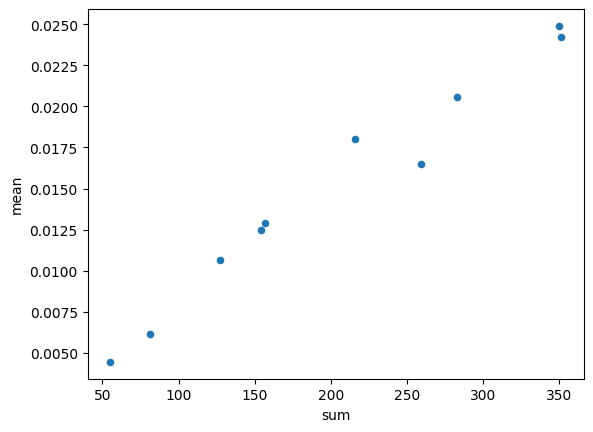

In [114]:
GROUP_SA.plot.scatter('sum','mean')
plt.show()

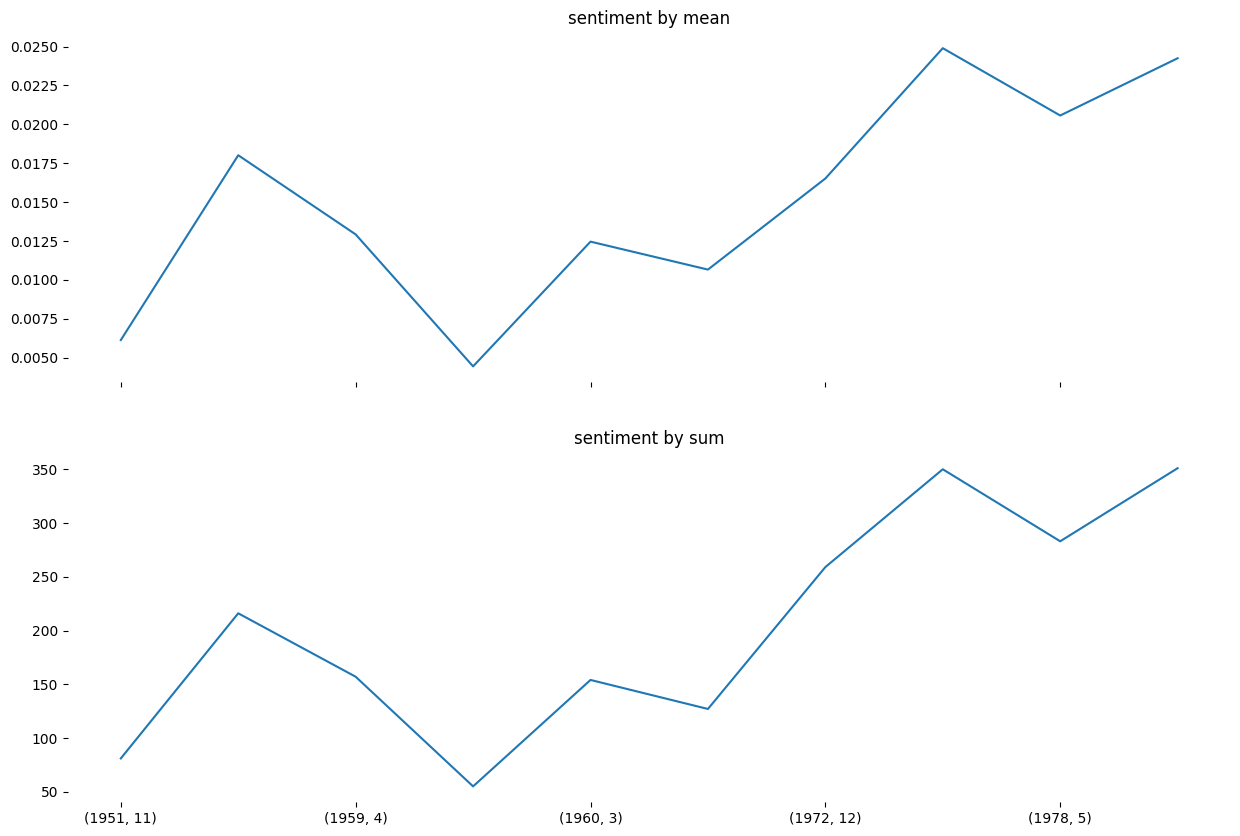

In [115]:
fig, axes = plt.subplots(2,1, figsize=(15,10), sharex=True)
for i, agg in enumerate(['mean','sum']):
    GROUP_SA[agg].plot(ax=axes[i], title=f"{emo_col} by {agg}")
sns.despine(left=True, bottom=True)
plt.xlabel("")
plt.show()

# Riff 3

In [116]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import download as nltk_download
nltk_download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/aniyahmcwilliams/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [117]:
analyser = SentimentIntensityAnalyzer()

In [118]:
TOKENS_SA

pos pos_group token_str  term_str  \
mag_id page_num token_num year month                                      
0      1        0         1972 12      DT        DT       The       the   
                1         1972 12      NN        NN      text      text   
                2         1972 12      IN        IN        on        on   
                3         1972 12      DT        DT      this      this   
                4         1972 12      NN        NN      page      page   
...                                   ...       ...       ...       ...   
9      68       55        1959 4      NNP        NN      INC.       inc   
                57        1959 4      NNP        NN  Michigan  michigan   
                58        1959 4      NNP        NN    Avenue    avenue   
                60        1959 4      NNP        NN   Chicago   chicago   
                62        1959 4      NNP        NN  Illinois  illinois   

                                           epub_id        date  \
mag_id page_num token_num year month                             
0      1        0         1972 12     vo8DAAAAMBAJ  1972-12-07   
                1         1972 12     vo8DAAAAMBAJ  1972-12-07   
                2         1972 12     vo8DAAAAMBAJ  1972-12-07   
                3         1972 12     vo8DAAAAMBAJ  1972-12-07   
                4         1972 12     vo8DAAAAMBAJ  1972-12-07   
...                                            ...         ...   
9      68       55        1959 4      mEEDAAAAMBAJ  1959-04-09   
                57        1959 4      mEEDAAAAMBAJ  1959-04-09   
                58        1959 4      mEEDAAAAMBAJ  1959-04-09   
                60        1959 4      mEEDAAAAMBAJ  1959-04-09   
                62        1959 4      mEEDAAAAMBAJ  1959-04-09   

                                                                                  pages  \
mag_id page_num token_num year month                                                      
0      1        0         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                1         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                2         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                3         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
                4         1972 12     ["\n\n\n\nThis book was produced in EPUB forma...   
...                                                                                 ...   
9      68       55        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                57        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                58        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                60        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   
                62        1959 4      ["\n\n\n\nThis book was produced in EPUB forma...   

                                          quarter  page_num  \
mag_id page_num token_num year month                          
0      1        0         1972 12     4th Quarter        68   
                1         1972 12     4th Quarter        68   
                2         1972 12     4th Quarter        68   
                3         1972 12     4th Quarter        68   
                4         1972 12     4th Quarter        68   
...                                           ...       ...   
9      68       55        1959 4      2nd Quarter        68   
                57        1959 4      2nd Quarter        68   
                58        1959 4      2nd Quarter        68   
                60        1959 4      2nd Quarter        68   
                62        1959 4      2nd Quarter        68   

                                                                                  title  \
mag_id page_num token_num year month                                                      
0      1        0

In [123]:
def tag_term_str(x):
    if pd.isna(x.sentiment):
        html_str = x.term_str
    else:
        html_str = f"<span class='sent{int(np.sign(x.sentiment))}'>{x.term_str}</span>"
    return html_str

In [124]:
TOKENS_SA['html'] = TOKENS_SA.apply(tag_term_str, axis=1)

In [125]:
MAG_SA = TOKENS_SA.groupby('mag_id')[emo_cols].mean()
MAG_SA['html_str'] = TOKENS_SA.groupby('mag_id')[['html']].apply(lambda x: ' '.join(map(str, x.html)))


In [127]:
MAG_SA

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment,html_str,mag_str
mag_id,,,,,,,,,,,
0,0.015308,0.023026,0.007718,0.017030,0.020602,0.020602,0.009249,0.035017,0.016520,<span class='sent0'>the</span> <span class='se...,NaN
1,0.012597,0.021666,0.007894,0.019903,0.018475,0.021918,0.007810,0.034431,0.010665,<span class='sent0'>what</span> <span class='s...,the text on this page is estimated to be only ...
2,0.013089,0.026391,0.007967,0.019064,0.025750,0.017783,0.010670,0.036207,0.024897,<span class='sent0'>nov</span> <span class='se...,warning the surgeon general has determined tha...
3,0.016209,0.024131,0.010249,0.019770,0.029147,0.021006,0.011775,0.038014,0.020570,<span class='sent0'>may</span> <span class='se...,editor and publisher john johnson executive ed...
4,0.011400,0.028465,0.006080,0.014509,0.029916,0.020727,0.011883,0.037792,0.024250,<span class='sent0'>one</span> <span class='se...,readers rap green home discussed dear editor r...
5,0.019995,0.026130,0.009392,0.023480,0.025600,0.026206,0.009846,0.034689,0.006135,<span class='sent0'>the</span> <span class='se...,duvalier ousts two cabinet members according t...
6,0.018207,0.024195,0.008820,0.024276,0.022981,0.023709,0.012866,0.038760,0.012462,<span class='sent0'>department</span> <span cl...,two law enforcement officers watch as tear gas...
7,0.016597,0.025354,0.007256,0.021685,0.027857,0.021101,0.011510,0.035613,0.018015,<span class='sent0'>jet</span> <span class='se...,standing in front of the building to leave the...
8,0.021736,0.024644,0.013413,0.025776,0.023836,0.026018,0.010666,0.036522,0.004444,<span class='sent0'>an</span> <span class='sen...,southern president etterville but in many blac...


In [129]:
MAG_SA['mag_str'] = TOKENS_SA.groupby(TOKENS_SA.index.get_level_values(1))[['term_str']].apply(lambda x: ' '.join(map(str, x.term_str)))
MAG_SA['mag_str'] = MAG_SA['mag_str'].fillna('')
VADER = MAG_SA.mag_str.apply(analyser.polarity_scores).apply(pd.Series)
VADER.head()


,neg,neu,pos,compound
mag_id,,,,
0,0.000,0.000,0.000,0.0000
1,0.081,0.832,0.088,-0.2263
2,0.061,0.811,0.128,0.9908
3,0.035,0.893,0.072,0.9982
4,0.074,0.772,0.154,0.9998


In [132]:
def plot_book_sa(mag_id, wf = 5):
    # wf: window size factor
    df = VADER.loc[mag_id]
    w = int(df.shape[0] / wf)
    fig, axes = plt.subplots(3, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle(mag_id, y=1, fontsize=20)
    df[['pos','neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

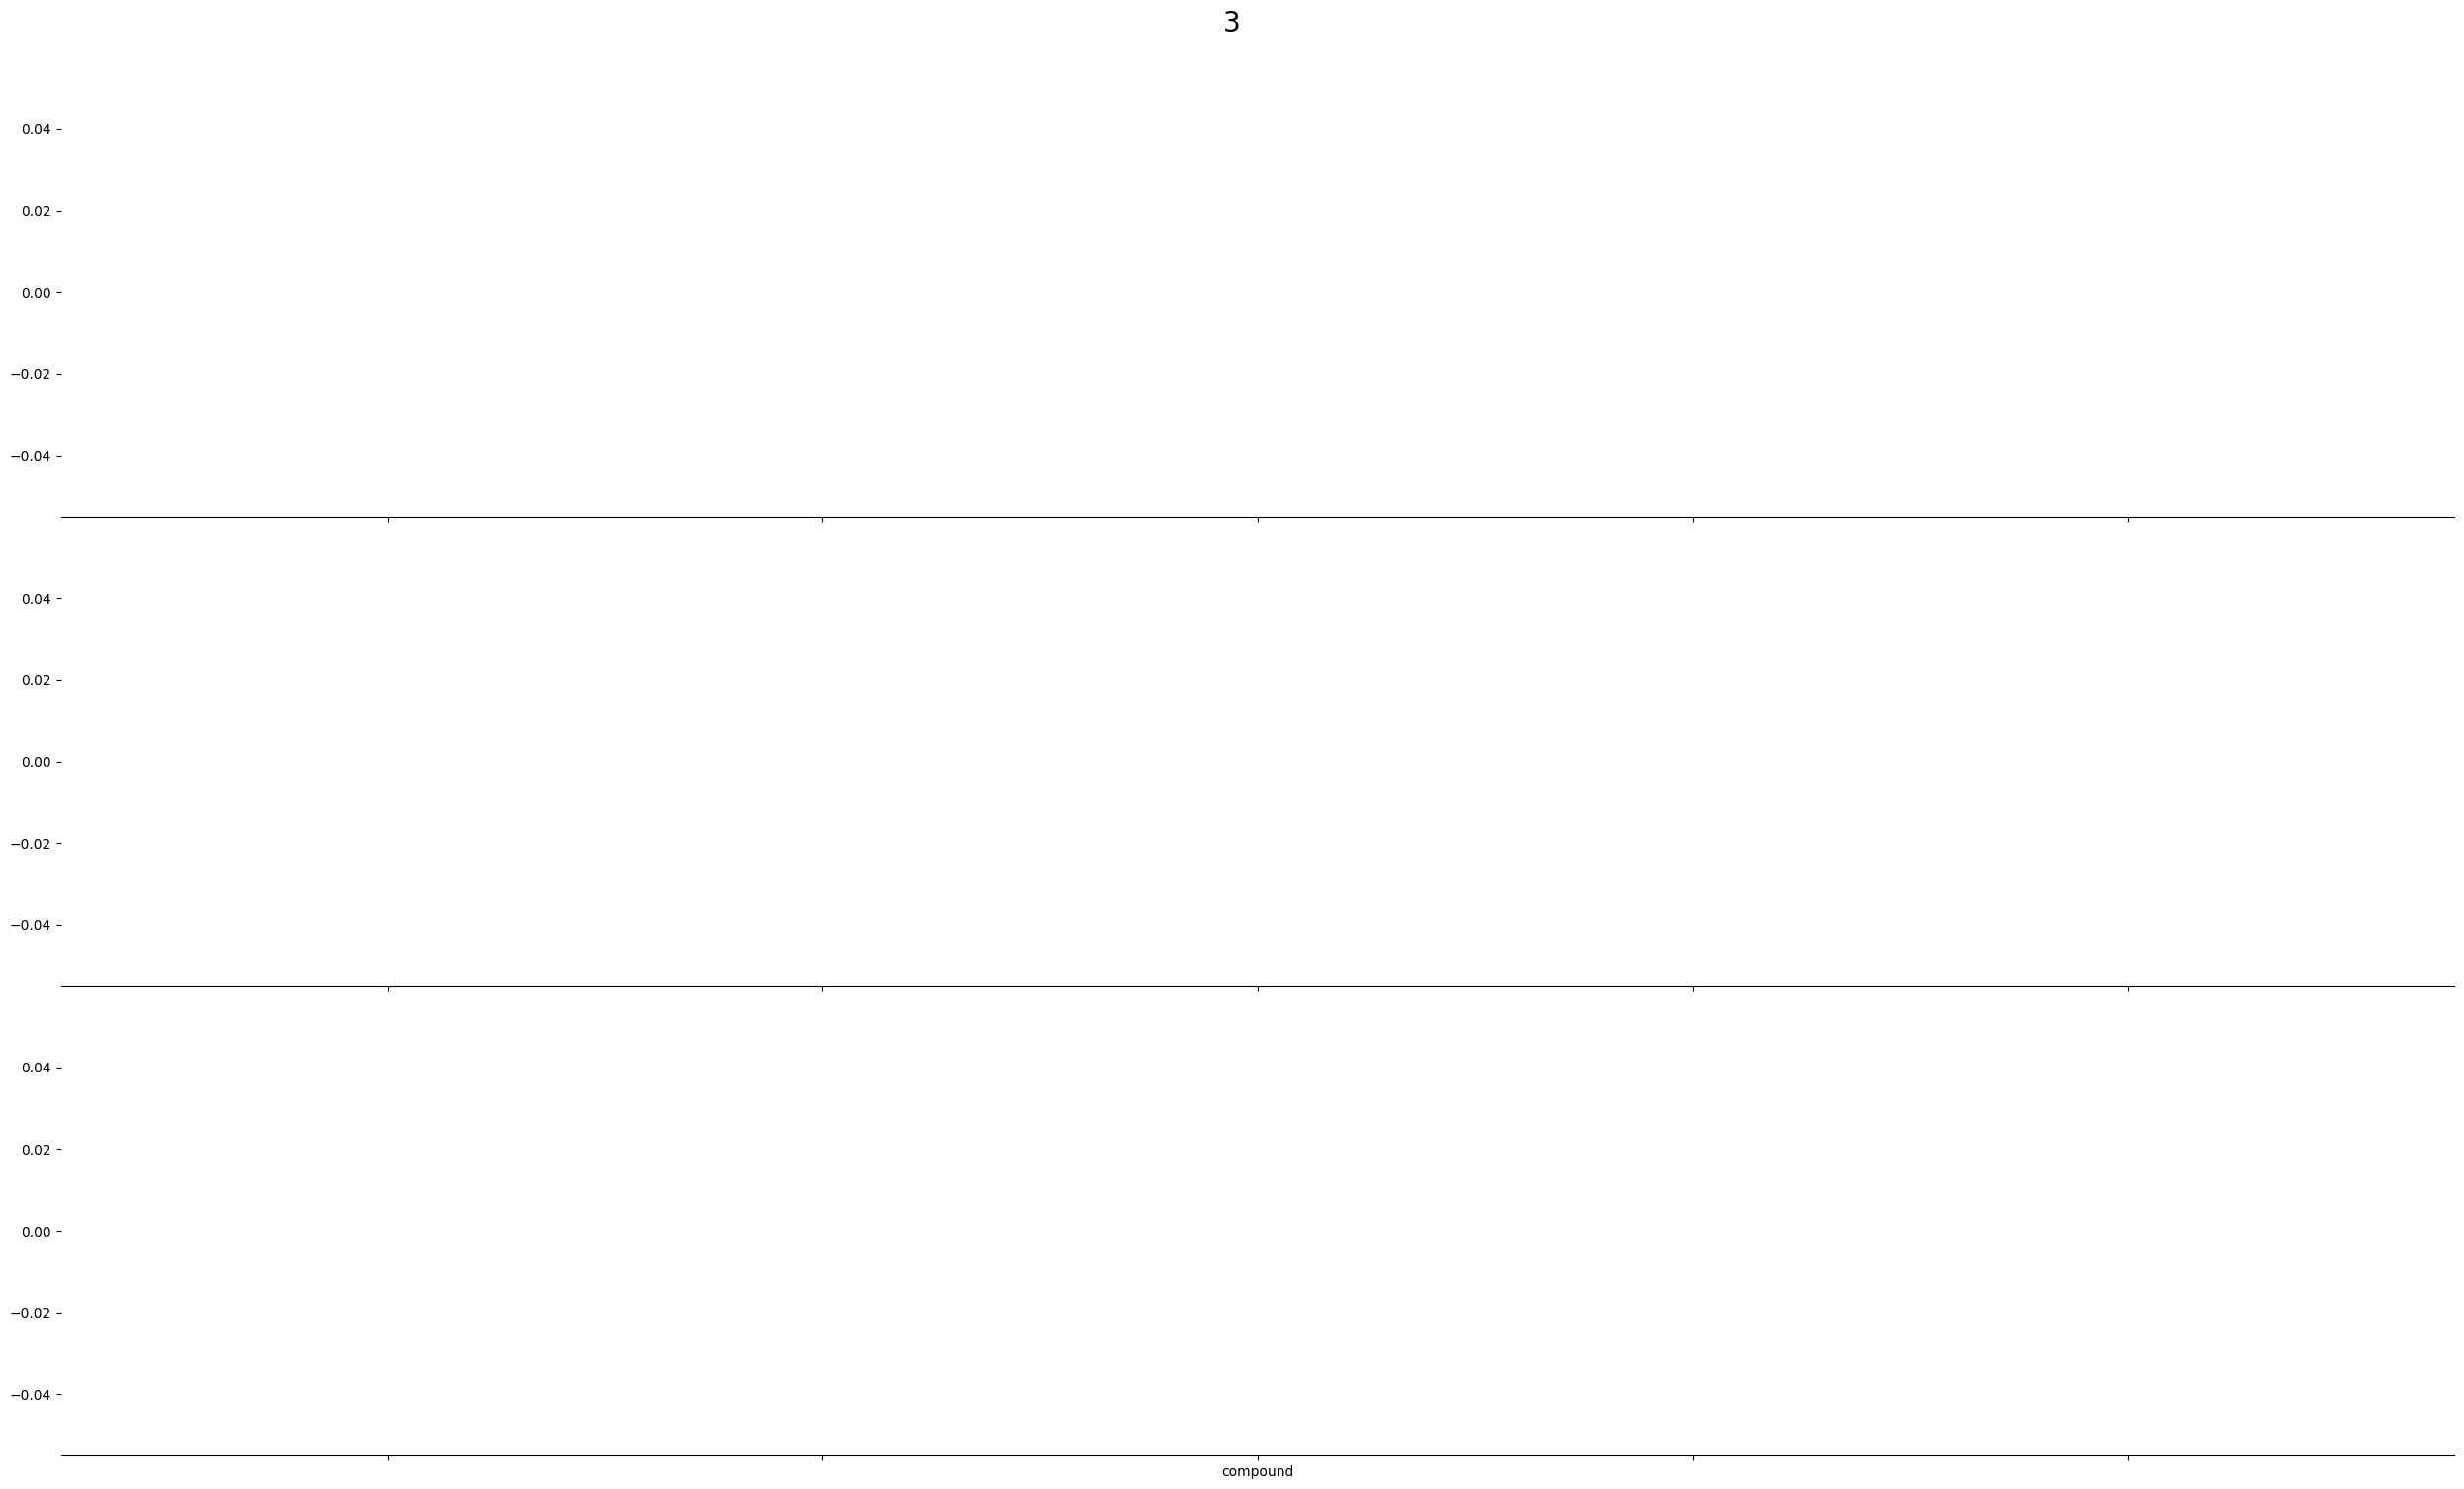

In [134]:
plot_book_sa(3)